In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr
import mne

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load decoding results

In [7]:
result_path

BIDSPath(
root: ../results/LexicalDelay(cross_roi)(bipolar)
datatype: (decode)(resolved)lexicality
basename: highgamma)

In [8]:
result_path.match()

[]

In [27]:
from scipy.ndimage import gaussian_filter1d

ref = 'bipolar'

task = 'LexicalDelay'
decode_type = 'lexicality'

result_path = BIDSPath(
    datatype=f'(cross)(resolved){decode_type}',
    root= f'../results/{task}(cross_roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['scores'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 1  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    df['pair'] = path.subject
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
scores = scores[scores.description=='Repeat']
# scores = scores[scores.phoneme=='1']
scores.head()

,time,fold,accuracy,baseline,p_value,pair,phase,hemi,description,datatype,band
1170,-0.80,0,0.563123,0.489412,0.468573,AICl2IFGl,Delay,Left,Repeat,(cross)(resolved)lexicality,highgamma
1171,-0.78,0,0.504584,0.488235,0.525467,AICl2IFGl,Delay,Left,Repeat,(cross)(resolved)lexicality,highgamma
1172,-0.76,0,0.412033,0.485294,0.556494,AICl2IFGl,Delay,Left,Repeat,(cross)(resolved)lexicality,highgamma
1173,-0.74,0,0.322406,0.495882,0.485787,AICl2IFGl,Delay,Left,Repeat,(cross)(resolved)lexicality,highgamma
1174,-0.72,0,0.278345,0.484706,0.452065,AICl2IFGl,Delay,Left,Repeat,(cross)(resolved)lexicality,highgamma


In [28]:
scores.pair.unique()

array(['AICl2IFGl', 'AICl2SMCl', 'AICl2STGl'], dtype=object)

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3005385/1948166643.py:22: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3005385/1948166643.py:22: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3005385/1948166643.py:22: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3005385/1948166643.py:22: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(


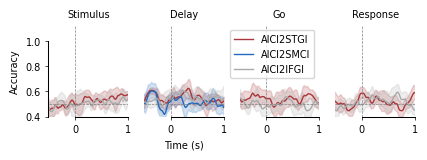

In [31]:
hue_order = ['AICl2STGl','AICl2SMCl', 'AICl2IFGl']
hemis = ['Left']
phases = ['Stimulus', 'Delay', 'Go', 'Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 1, 0.03, 0.02
chance = 0.5
ymin = 0.4

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 2 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='pair',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, pair in enumerate(hue_order):
        roi_data = subset[(subset.pair == pair) & (subset.fold == 1)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.05)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.5, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[2].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')

# plt.tight_layout()
# fig.savefig(f'../img/fig3/fig3_{task}_{decode_type}.svg', dpi=300, bbox_inches='tight')
plt.show()